In [1]:
import astromugs.modeling as modeling
import astromugs.dust as dust

In [1]:
## Advice for user: create a folder with the model's name and add thermal/ e.g. your_path/model_name/thermal/
# This way, both the chemistry and thermal results will be stored in the same parent folder your_path/model_name/.
thermpath='/Users/sacha/science/projects/phantom_gonzalez/model1/simulations/sim_6000K_Lsun4/thermal/'
#chempath='/Users/sacha/science/projects/phantom_gonzalez/model1/simulations/sim_4000K_Lsun1/chemistry/'

In [3]:
drift = modeling.Interface()  

In [4]:

drift.add_thermal_path(thermpath)
#drift.add_chemistry_path(chempath)

In [5]:
drift.params.disk.ref_radius = 100 ##
drift.params.disk.tmidplan_ref = 10 ##
drift.params.disk.nr = 101 ##
drift.params.disk.rin = 10
drift.params.disk.rout = 500
drift.params.disk.star_mass = 1.
drift.params.disk.sigma_compute = 'custom'
drift.params.disk.sigma_path = 'convert/surface_densities.txt'

In [6]:
drift.params

Field,Type,Value,Description
acc_rate,float,1.000e-05,[Msun yr-1] Accretion rate
cav_fact,float,1.000e+01,Factor of decrease of the density in the cavity
cavpl,float,1.000e+00,Opening angle and shape of the outflow
cavz0,float,1.000e+01,[AU]
coordsystem,Literal,'spherical',Coordinate system for radiative transfer
dtogas,float,1.000e-02,Dust to gas mass ratio
dust_env_mass,float,1.000e-05,[Msun] Total dust mass of the envelope
r_centri,float,1.000e+02,[AU] Centrifugal radius (critical radius inside of which the envelope flattens)
rmax,float,5.000e+03,[AU] Outer radius of the envelope)
rmin,float,1.000e+00,[AU] inner radius of the envelope)


In [7]:
drift.thermalparams.control.itempdecoup = 1
drift.thermalparams.control.nphot_therm = 8e6
drift.thermalparams.control.nphot_scat = 8e6
drift.thermalparams.control.nphot_mono = 8e6
drift.thermalparams.control.scattering_mode_max = 5
drift.thermalparams.control.modified_random_walk = 1

drift.thermalparams.star.mass = drift.params.disk.star_mass
drift.thermalparams.star.luminosity = 4
drift.thermalparams.star.temperature = 6000

In [8]:
drift.thermalparams

Field,Type,Value,Description
incl_dust,float,None,"Switch to include dust continuum emission (0=off, 1=on)"
incl_lines,float,None,"Switch to include line emission (0=off, 1=on)"
incl_freefree,float,None,"Switch to include free-free emission (0=off, 1=on)"
nphot_therm,float,8.000e+06,Number of photon packages for thermal Monte Carlo
nphot_scat,float,8.000e+06,Number of photon packages for scattering Monte Carlo
nphot_mono,float,8.000e+06,Number of photon packages for monochromatic Monte Carlo
nphot_spec,float,None,Number of photon packages for spectrum calculation
iseed,int,None,Random number generator seed
ifast,float,None,Fast method for thermal emission computation (1=on)
enthres,float,None,Energy threshold for thermal Monte Carlo convergence


In [9]:
drift.grid.set_wavelength_grid(9.12e-2, 1e4, 200, log=True) #microns

In [10]:
drift.grid.set_mcmonowavelength_grid(9.12e-2, 1e2, 50, log=True)

In [11]:
# #-----ADD STARS-----
drift.add_star() #note that if you enter this multiple times, it will keep adding stars.

In [12]:
# #-----DEFINE SPHERICAL GRID-----
drift.grid.set_spherical_grid()

In [13]:
drift.write_continuum(
    control=True,
    stars=True,
    wave=True,
    grid=True,
    mcmono=True
)


Writing radmc3d.inp:
----------------------------

Writing stars.inp:
----------------------------

Writing wavelength_micron.inp:
----------------------------

Writing mcmono_wavelength_micron.inp:
----------------------------

Writing amr_grid.inp:
----------------------------


In [2]:
# the user can use an independent path here because most of the time the dust_size file is somewhere else, for instance in MHD outputs.
d = dust.CustomDistrib(rho_m=3.3, path="/Users/sacha/science/projects/phantom_gonzalez/model1/simulations/sim_8000K_lum6/thermal/") #microns


In [ ]:
drift.grid.add_dust(d)

In [12]:
d.sizes()[0][2]

np.float64(4.7)

In [15]:
drift.add_disk(dust=d)

In [16]:
drift.write_continuum(
    dens=True
)


Writing dust_density.inp:
----------------------------
number of structures (disk, envelope...):  1 

number of species in structure 1:  9
total number of grain species:  9


In [17]:
#MAKE sure you have the dustkap files in the folder before running this.

drift.write_continuum(
    opac=True
)


Writing dustopac.inp:
----------------------------


In [18]:
# In most cases, this command should never be used. However, it may happens sometimes that the path to radmc3d is specific,
# so the user can directly tell astroMUGS "please use this path for radmc3d". 
drift.radmc3d_cmd = '/Users/sacha/bin/radmc3d'


In [19]:
#Simply run the mctherm using the parameters defined above.
drift.run_continuum()

  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github                     
             https://github.com/dullemond/radmc3d-2.0            
                                                                 
       

In [3]:
from astromugs.plotting import plot

In [4]:
thermpath='/Users/sacha/science/projects/phantom_gonzalez/model1/simulations/sim_6000K_Lsun4/thermal/'

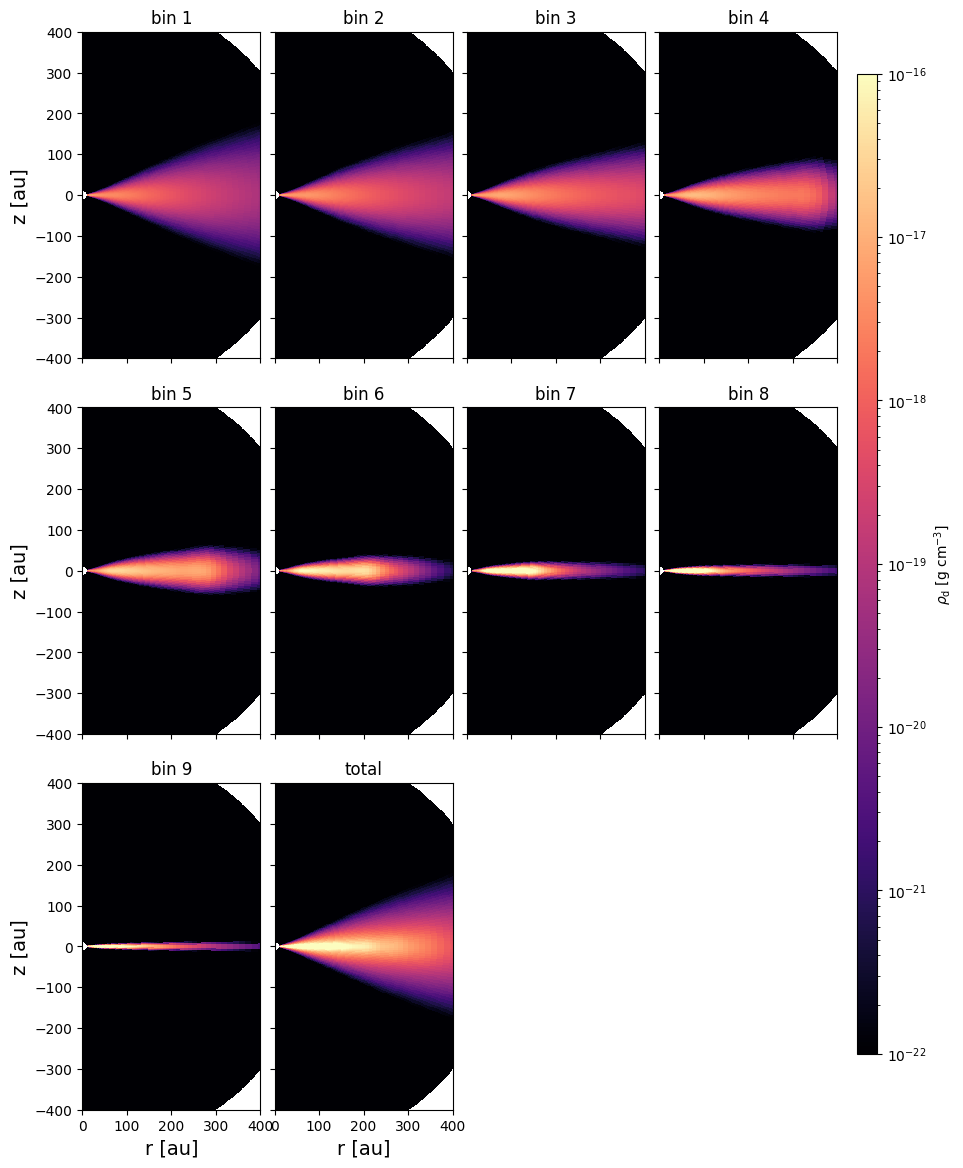

In [6]:
plot.density2D_grid(path=thermpath, vmin=1e-22, vmax=1e-16, xlim=(0, 400), ylim=(-400, 400), cmap='magma', dens_type='mass')

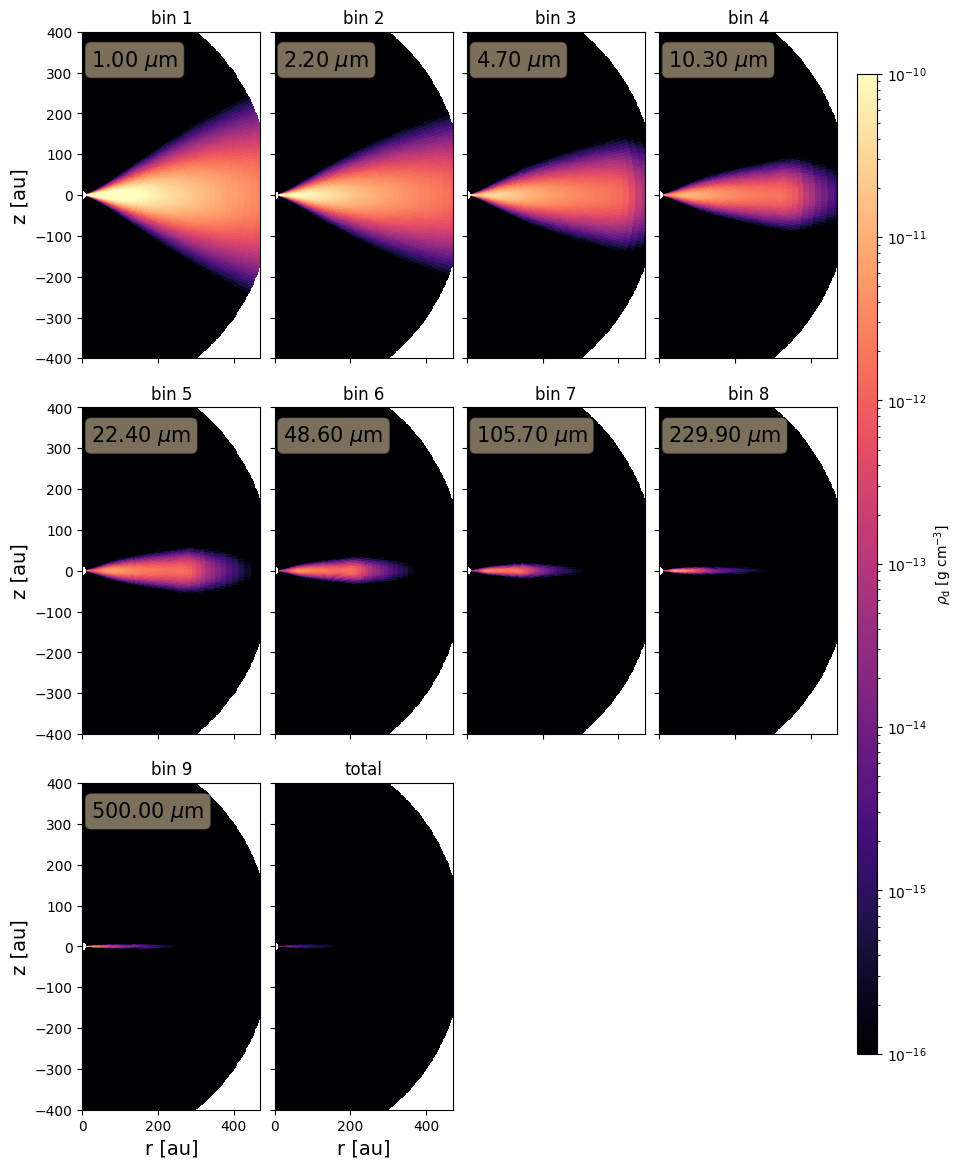

In [5]:
plot.density2D_grid(path=thermpath, vmin=1e-16, vmax=1e-10, xlim=(0, 470), ylim=(-400, 400), cmap='magma', dust=d, dens_type='number')

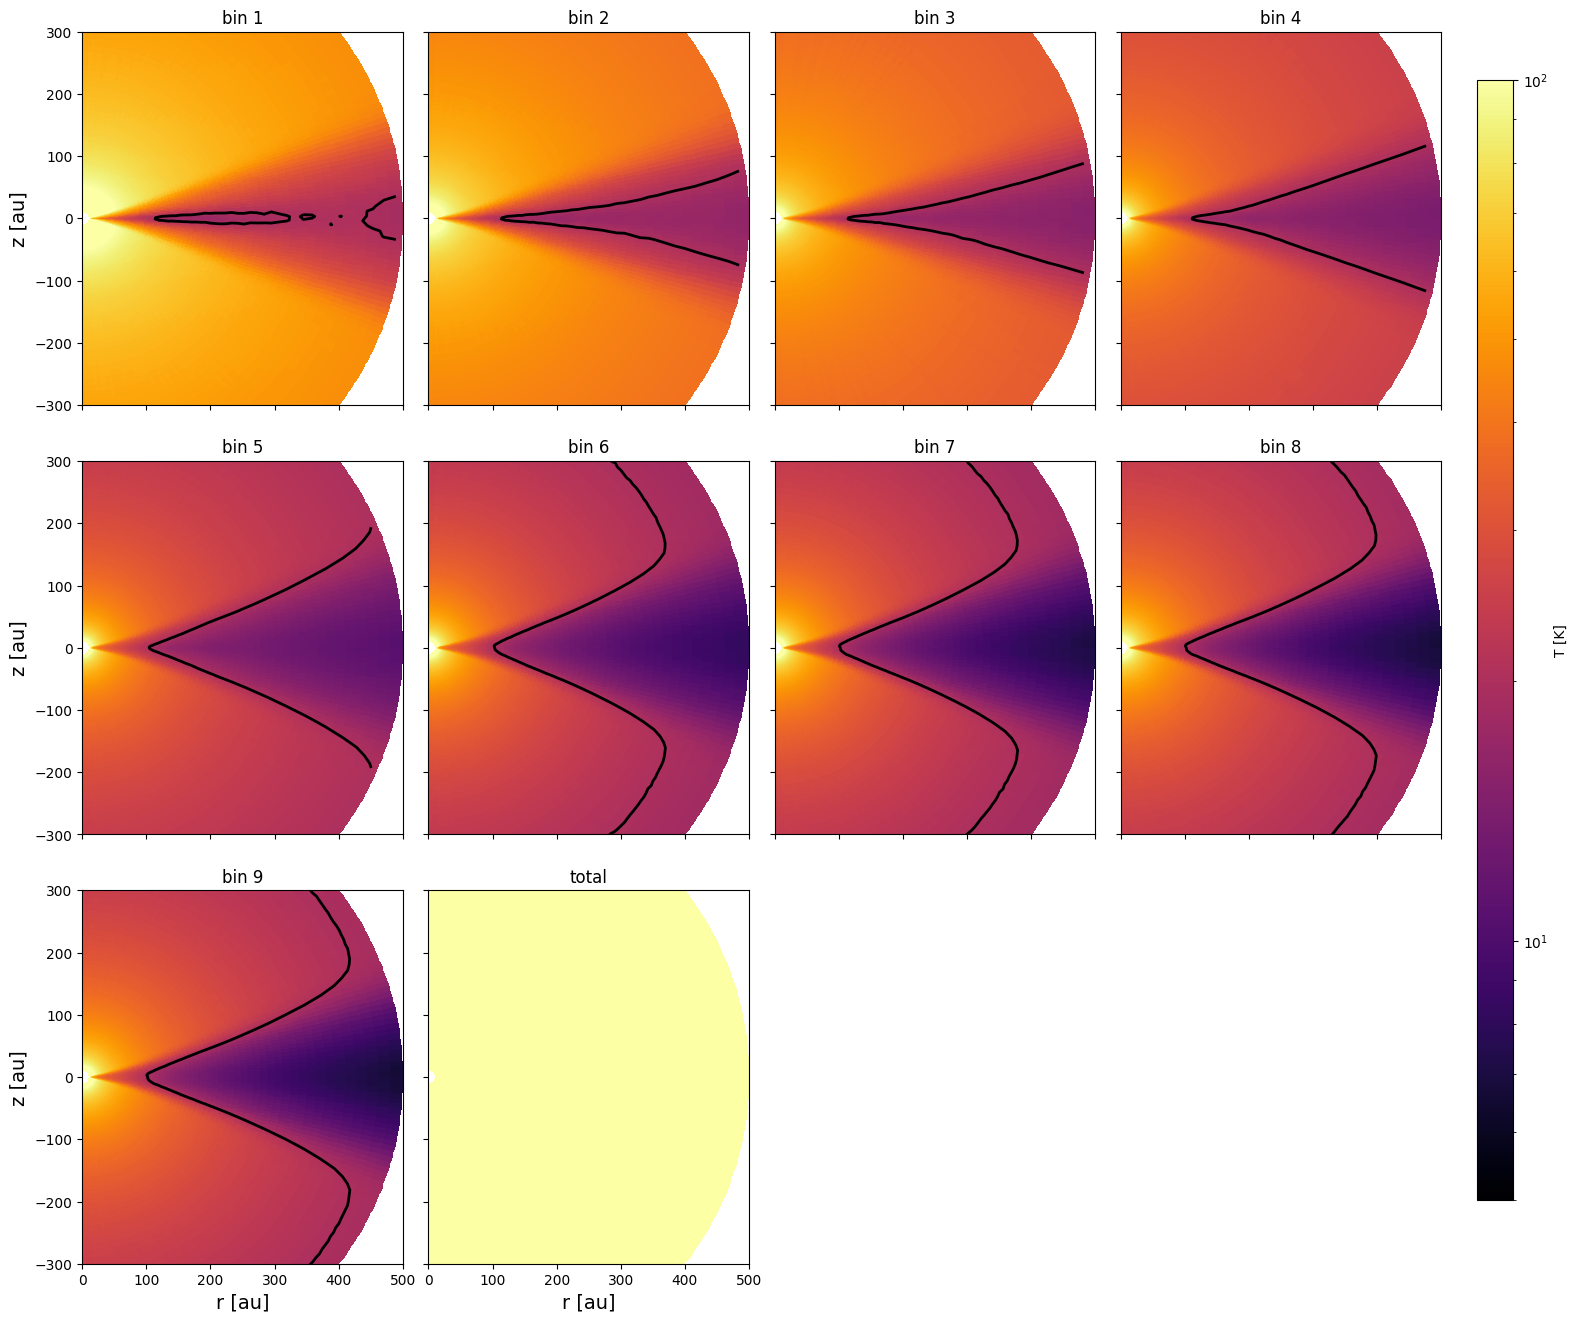

In [6]:
plot.temperature2D_grid(path=thermpath, vmin=5, vmax=1e2, xlim=(0, 500), ylim=(-300, 300), cmap='inferno')

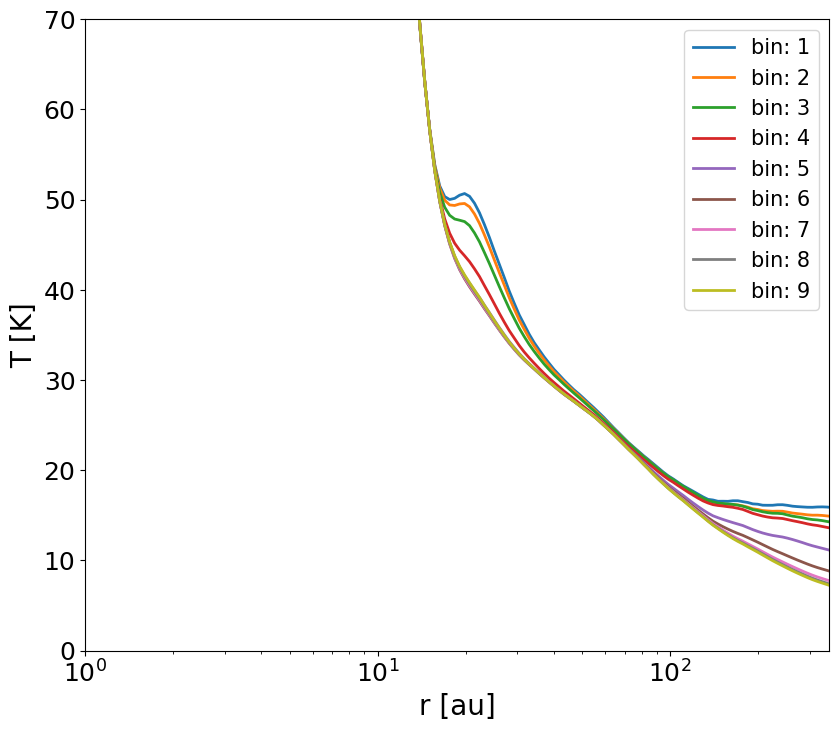

In [57]:
plot.midplane_temp(path=thermpath, xlim=(1, 350), ylim=(0, 70))

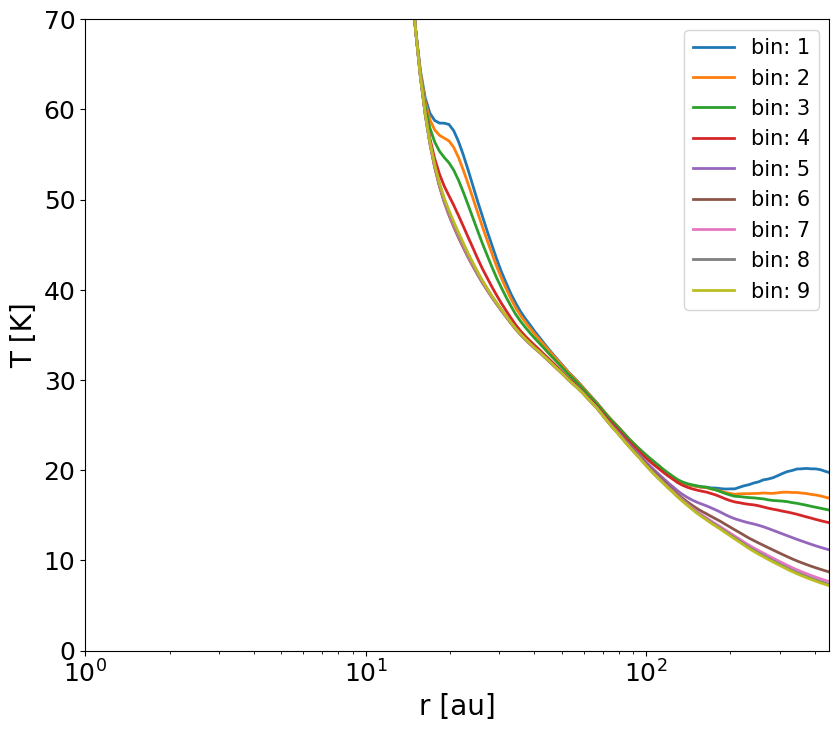

In [23]:
plot.midplane_temp(path=thermpath, xlim=(1, 450), ylim=(0, 70))

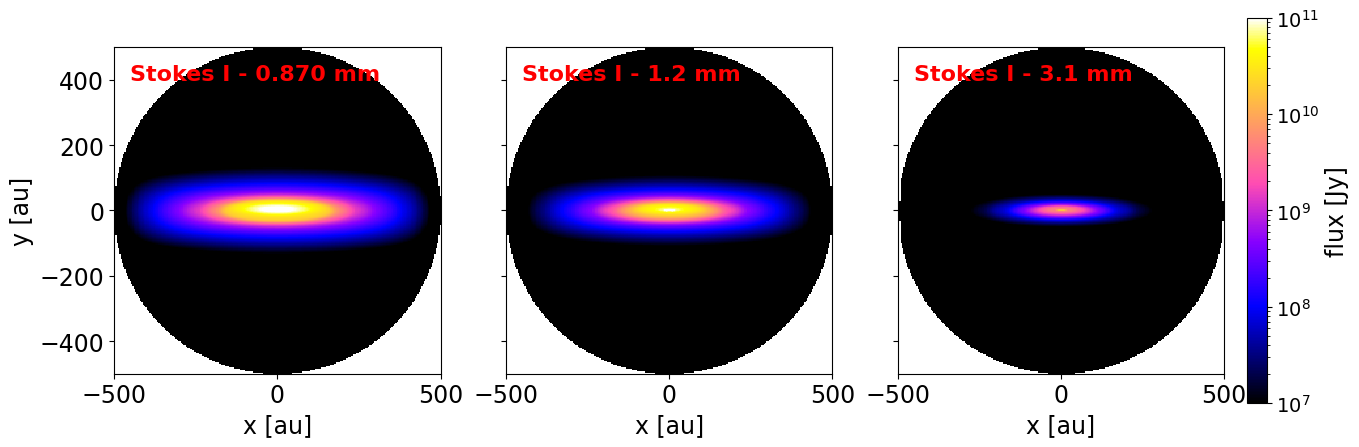

In [5]:
plot.image(pathfile='thermal/image_incl80.out', vmin=1e7, vmax=1e11, cmap='gnuplot2')

97

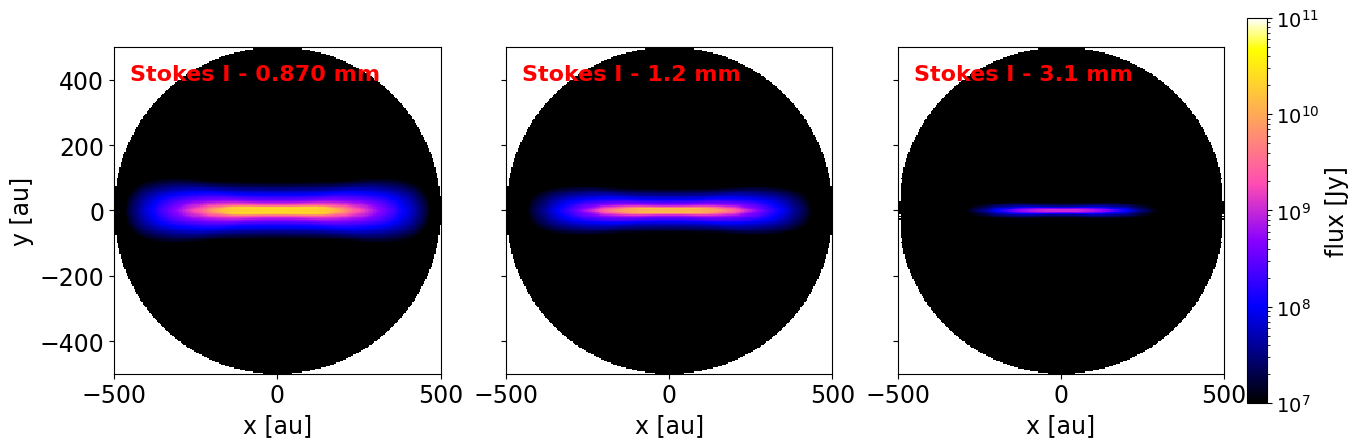

In [4]:
plot.image(pathfile='thermal/image_incl90.out', vmin=1e7, vmax=1e11, cmap='gnuplot2')

493.63057324840764

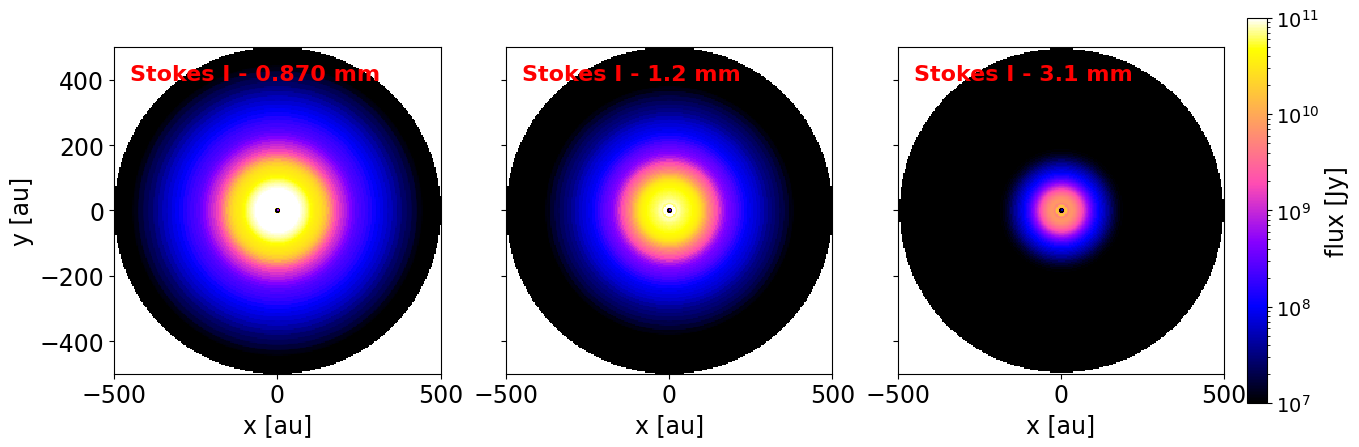

In [3]:
plot.image(pathfile='thermal/image_xy.out', vmin=1e7, vmax=1e11, cmap='gnuplot2')


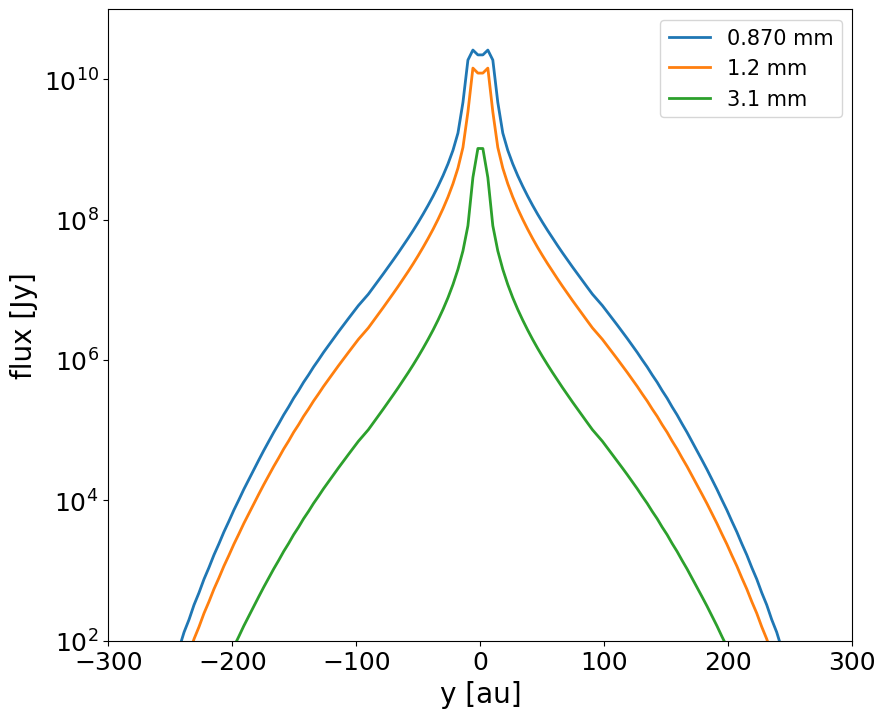

In [2]:
plot.image_vertical_cut(pathfile='thermal/image_incl90.out', xlim=(-300, 300), ylim=(1e2, 1e11), labels=None, figsize=(9.6, 8.2))

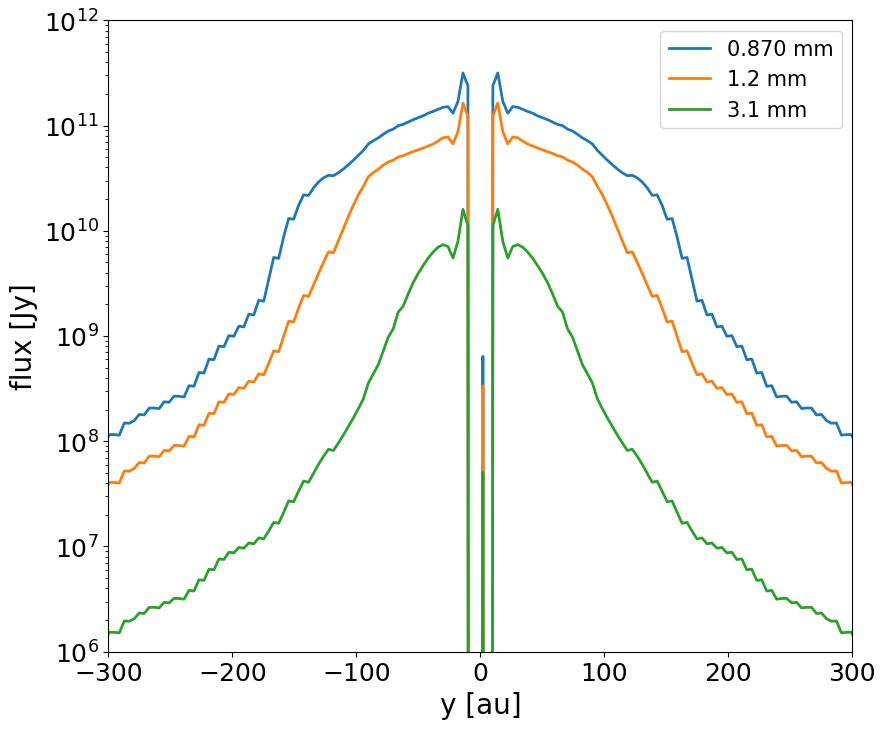

In [5]:
plot.image_vertical_cut(pathfile='thermal/image_xy.out', xlim=(-300, 300), ylim=(1e6, 1e12), labels=None, figsize=(9.6, 8.2))

In [7]:
import os

In [8]:
USE_GPU = os.environ.get("USE_GPU", "0") == "1"

In [9]:
USE_GPU

False

In [ ]:
s